___

In [ ]:
import pandas as pd

# Load datasets
df_train = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_go_emotion_processed_featured.csv")
df_test = pd.read_csv(r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv")

# Print original column names
print("Original training dataset columns:", df_train.columns.tolist())
print("Test dataset columns:", df_test.columns.tolist())

# Define column name mapping
column_rename = {
    'happy': 'happiness',
    'sad': 'sadness',
    'disgusted': 'disgust',
    'mad': 'anger',
    'scared': 'fear',
    'surprised': 'surprise'
    # 'neutral' remains the same
}

# Rename columns in training dataset
df_train = df_train.rename(columns=column_rename)

# Verify the rename worked
print("\nAfter renaming, training dataset columns:", df_train.columns.tolist())

# Now define the standardized emotion columns
emotion_cols = ['happiness', 'sadness', 'disgust', 'anger', 'fear', 'surprise', 'neutral']

# Check that both datasets have these columns
print("\nTraining data has all emotion columns:", all(col in df_train.columns for col in emotion_cols))
print("Test data has all emotion columns:", all(col in df_test.columns for col in emotion_cols))

# Now we can continue with creating the emotion and emotion_code columns
df_train['emotion'] = df_train[emotion_cols].idxmax(axis=1)
df_test['emotion'] = df_test[emotion_cols].idxmax(axis=1)

# Create numeric codes
emotion_code_mapping = {
    'happiness': 0,
    'sadness': 1,
    'disgust': 2,
    'anger': 3,
    'fear': 4,
    'surprise': 5,
    'neutral': 6
}

# Apply the mapping
df_train['emotion_code'] = df_train['emotion'].map(emotion_code_mapping)
df_test['emotion_code'] = df_test['emotion'].map(emotion_code_mapping)

# Check the distribution
print("\nTraining data emotion distribution:")
print(df_train['emotion'].value_counts())

print("\nTest data emotion distribution:")
print(df_test['emotion'].value_counts())

___

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Input, Embedding, Bidirectional, GRU, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [2]:
# Load the preprocessed datasets
train_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_go_emotion_processed_featured.csv"
test_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\1_testing_dataset_g21_mapped_processed_featured.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Create sentiment features
df_train['emotional_intensity'] = df_train['VADER_Positive'] + df_train['VADER_Negative']
df_train['sentiment_direction'] = df_train['TextBlob_Polarity'] * df_train['VADER_Compound']

df_test['emotional_intensity'] = df_test['VADER_Positive'] + df_test['VADER_Negative']
df_test['sentiment_direction'] = df_test['TextBlob_Polarity'] * df_test['VADER_Compound']

In [3]:
# Define sentiment features
sentiment_features = ['TextBlob_Polarity', 'VADER_Compound', 'emotional_intensity', 
                    'sentiment_direction', 'VADER_Positive', 'VADER_Negative']

In [4]:
# Extract text, sentiment features, and emotions
X_train_text = df_train['text'].values
X_train_sentiment = df_train[sentiment_features].values
y_train = df_train['emotion_code'].values

X_test_text = df_test['text'].values
X_test_sentiment = df_test[sentiment_features].values
y_test = df_test['emotion_code'].values

In [5]:
# Scale sentiment features
scaler = StandardScaler()
X_train_sentiment_scaled = scaler.fit_transform(X_train_sentiment)
X_test_sentiment_scaled = scaler.transform(X_test_sentiment)


In [6]:
# Convert emotions to one-hot encoded vectors
num_classes = 7  # 0-6 for emotion classes
y_train_onehot = to_categorical(y_train, num_classes=num_classes)
y_test_onehot = to_categorical(y_test, num_classes=num_classes)

In [14]:
# Tokenize and sequence the text data
max_words = 10000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)

In [15]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Split training data into train and validation
X_train_text_data, X_val_text_data, X_train_sent_data, X_val_sent_data, y_train_data, y_val_data = train_test_split(
    X_train_pad, X_train_sentiment_scaled, y_train_onehot, test_size=0.2, random_state=42)

In [16]:
# 2. Define model architecture
def build_improved_model(vocab_size, embedding_dim=100, max_length=100, sentiment_features=6):
    # Text input branch with stronger regularization
    text_input = Input(shape=(max_length,), name='text_input')
    
    # Add regularization to embedding
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                         embeddings_regularizer=tf.keras.regularizers.l2(1e-5))(text_input)
    
    # Simplify to a single GRU layer with stronger dropout
    text_gru = Bidirectional(GRU(48, return_sequences=False,
                                recurrent_regularizer=tf.keras.regularizers.l2(1e-5)))(embedding)
    text_gru = Dropout(0.5)(text_gru)  # Increased dropout
    
    # Sentiment input branch - simpler
    sentiment_input = Input(shape=(sentiment_features,), name='sentiment_input')
    sentiment_dense = Dense(24, activation='relu', 
                           kernel_regularizer=tf.keras.regularizers.l2(1e-5))(sentiment_input)
    sentiment_dense = Dropout(0.4)(sentiment_dense)
    
    # Combine branches
    combined = Concatenate()([text_gru, sentiment_dense])
    
    # Simpler fully connected layers with L2 regularization
    dense = Dense(48, activation='relu', 
                 kernel_regularizer=tf.keras.regularizers.l2(1e-5))(combined)
    dense = Dropout(0.5)(dense)
    
    # Output layer
    output = Dense(num_classes, activation='softmax')(dense)
    
    model = Model(inputs=[text_input, sentiment_input], outputs=output)
    return model

# 3. Setup training aids
# Class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

# Text augmentation
def augment_text(text_sequences, drop_percent=0.1):
    """Simple word dropout augmentation"""
    augmented = np.copy(text_sequences)
    mask = np.random.rand(*augmented.shape) >= drop_percent
    augmented = augmented * mask
    return augmented

X_train_text_augmented = augment_text(X_train_text_data)

# 4. Create and compile model
vocab_size = min(max_words, len(tokenizer.word_index) + 1)
model = build_improved_model(vocab_size=vocab_size, sentiment_features=len(sentiment_features))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 100, 100)     1000000     ['text_input[0][0]']             
                                                                                                  
 sentiment_input (InputLayer)   [(None, 6)]          0           []                               
                                                                                                  
 bidirectional (Bidirectional)  (None, 96)           43200       ['embedding[0][0]']              
                                                                                              

In [17]:
# Train model
history = model.fit(
    [X_train_text_augmented, X_train_sent_data],
    y_train_data,
    validation_data=([X_val_text_data, X_val_sent_data], y_val_data),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
4296/4296 [==============================] - 146s 31ms/step - loss: 1.7733 - accuracy: 0.3351 - val_loss: 1.6440 - val_accuracy: 0.3537 - lr: 5.0000e-04
Epoch 2/20
4296/4296 [==============================] - 133s 31ms/step - loss: 1.5756 - accuracy: 0.3908 - val_loss: 1.5183 - val_accuracy: 0.4091 - lr: 5.0000e-04
Epoch 3/20
4296/4296 [==============================] - 137s 32ms/step - loss: 1.5015 - accuracy: 0.4029 - val_loss: 1.5592 - val_accuracy: 0.4069 - lr: 5.0000e-04
Epoch 4/20
4296/4296 [==============================] - 133s 31ms/step - loss: 1.4540 - accuracy: 0.4093 - val_loss: 1.5196 - val_accuracy: 0.4093 - lr: 5.0000e-04
Epoch 5/20
4296/4296 [==============================] - 134s 31ms/step - loss: 1.3523 - accuracy: 0.4283 - val_loss: 1.5082 - val_accuracy: 0.4097 - lr: 1.0000e-04
Epoch 6/20
4296/4296 [==============================] - 127s 29ms/step - loss: 1.3273 - accuracy: 0.4305 - val_loss: 1.4949 - val_accuracy: 0.4138 - lr: 1.0000e-04
Epoch 7/20
4296/

In [18]:
# Evaluate model
test_loss, test_accuracy = model.evaluate([X_test_pad, X_test_sentiment_scaled], y_test_onehot, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

27/27 [==============================] - 1s 19ms/step - loss: 1.4035 - accuracy: 0.4791

Test Accuracy: 0.4791


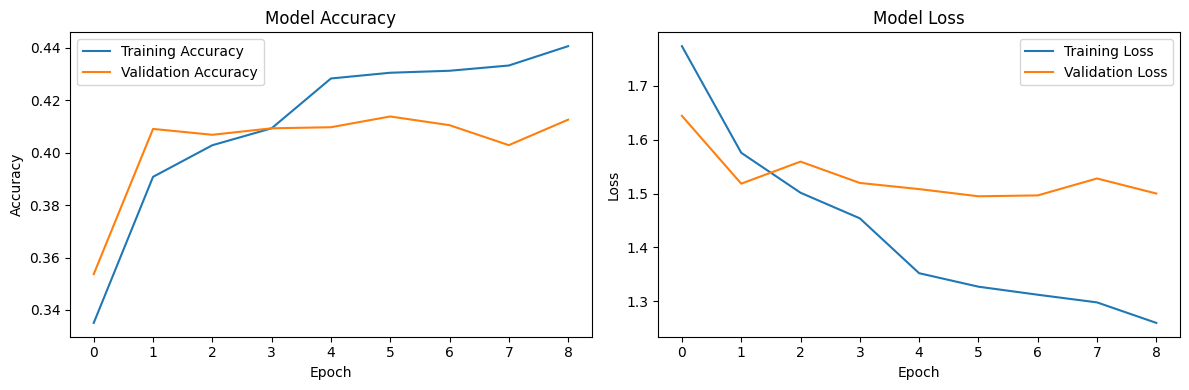

In [19]:
# 7. Optional: Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()